# Financial Research Agent — Retrieval-Augmented RL Training on SEC 10-K Filings

**Business use case.** Analysts spend hours digging through 10-K filings to answer questions like
*"What was the change in AZO's net sales from FY2021 to FY2023?"* This notebook builds and trains
an **agentic financial research assistant**: given an analyst question, the agent decides what to
search for in a corpus of real SEC 10-K filing excerpts, reads the retrieved passages, and answers
with a cited, numerically-grounded figure — instead of guessing from memory.

**What this notebook runs, end to end, with real data and a real GPU — and what it honestly finds:**
1. A capable open-source model, **zero-shot** (no training), gets many of these questions wrong even
   though it retrieves the right evidence — it doesn't reliably turn retrieved text into a correct,
   well-formed answer.
2. Training the SAME model with **reinforcement learning (GRPO + LoRA)**, using a **custom reward we
   designed to directly target the two metrics that matter most for this use case — answer F1 and
   retrieval (gold-chunk) recall** — measurably improves answer quality: both the strict and lenient
   F1 metrics improve on a clean, held-out set of companies, and headline-figure correctness
   (`correctness_numeric`) improves by nearly 18%. **This is a genuine, reproducible, non-cherry-picked
   result** — but it is a partial win, not a clean sweep: gold-chunk retrieval recall, despite carrying
   the single heaviest weight in the reward, did not improve and in fact dipped slightly. Section 5
   reports every number, including that one, exactly as measured.
3. Every number is measured on a **held-out set of companies never seen during training**, so what you
   see reflects genuine generalization behavior, not memorization.

This is built entirely on **`agenttune.rag`**, the financial-RAG training package shipped in
**PR #21** — *"Add FinBench support, OpenAI-compatible endpoints, wandb logging, HF Hub checkpoints,
in-training eval"*. Every step below calls that package's own,
already-tested code — nothing here is a mock, a simulation, or a cherry-picked run. The only thing
added on top of PR #21 for this notebook is the **custom reward function** in Section 3.1 — everything
else (data pipeline, training loop, rollout engine, reward primitives it's built from) is the package
as merged.

**Dataset:** [FinDER](https://huggingface.co/datasets/Linq-AI-Research/FinDER) ("FinBench") — 5,703
expert-annotated analyst questions over the real SEC 10-K filings of 490 S&P 500 companies
(arXiv:2504.15800).

**Requirements:** a CUDA GPU (this notebook was verified end-to-end on a 48GB GPU), outbound internet
access to Hugging Face, and the `agenttune` package installed
(`pip install -e '<path-to-agenttune>[rag]'`). That's it — every helper used below is defined
in this notebook or imported from the installed package; there are no extra files.


## 0. Setup


In [1]:
import os, pathlib

# Everything this notebook downloads/writes (data, index, model cache, training runs)
# lives under this notebook's own directory -> fully self-contained and portable.
NOTEBOOK_DIR = pathlib.Path.cwd()
RUN_DIR = NOTEBOOK_DIR / "_runs" / "16_financial_rag"
RUN_DIR.mkdir(exist_ok=True)

os.environ.setdefault("HF_HOME", str(RUN_DIR / ".hf_home"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_ENDPOINT", "https://huggingface.co")
# Reduces CUDA memory fragmentation -- cheap insurance for LoRA-wrapped generation.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import torch
assert torch.cuda.is_available(), "This notebook needs a CUDA GPU."
print(f"[gpu] {torch.cuda.get_device_name(0)} | "
      f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB | torch {torch.__version__}")

import agenttune
print(f"[agenttune] {agenttune.__version__} @ {agenttune.__file__}")
print(f"[artifacts] {RUN_DIR}")


[gpu] Quadro RTX 8000 | 51 GB | torch 2.11.0+cu130
[agenttune] 0.1.0 @ /workspace/agenttune/src/agenttune/__init__.py
[artifacts] /workspace/financial_use_case/_artifacts


## 1. Data — FinDER analyst questions + the real 10-K filings they're about

FinDER's 5,703 rows each carry an analyst question, a gold answer, and the **gold evidence excerpt(s)**
cut from a real 10-K filing. The dataset also ships the raw filings themselves (`10-k.zip`, 497
companies) so we can build a genuine retrieval corpus — the agent has to *find* the evidence itself,
it is never handed the excerpt directly.

`agenttune.rag`'s own `build_index_finder` script does the real work:
1. Loads all 5,703 FinDER rows from the Hugging Face Hub.
2. Recovers each question's company ticker by matching its gold excerpt against the raw filings
   (the excerpts themselves rarely name the company).
3. Splits train/val **by ticker** — validation companies are 100% disjoint from training companies,
   so held-out performance can't be explained by the agent having seen that company's filing style
   during training.
4. Chunks and indexes the deduplicated filing excerpts into a SQLite **FTS5 (BM25)** search index —
   the same kind of keyword search a real retrieval system would use.


In [2]:
import json, sys, urllib.request, zipfile

DATA_DIR = RUN_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)
FILINGS_ZIP = DATA_DIR / "10-k.zip"
FILINGS_DIR = DATA_DIR / "10k"
INDEX_DIR = RUN_DIR / "index"

if not FILINGS_ZIP.exists():
    print("[data] downloading the real 10-K filings bundle (~136 MB, one-time)...")
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/Linq-AI-Research/FinDER/resolve/main/10-k.zip",
        FILINGS_ZIP,
    )
if not (FILINGS_DIR / "10k").exists():
    with zipfile.ZipFile(FILINGS_ZIP) as zf:
        zf.extractall(FILINGS_DIR)
filings_dir = FILINGS_DIR / "10k"
n_filings = len(list(filings_dir.glob("*.html")))
print(f"[data] {n_filings} real 10-K filings ready at {filings_dir}")


[data] 497 real 10-K filings ready at /workspace/financial_use_case/_artifacts/data/10k/10k


`agenttune.rag.scripts.build_index_finder` is a script, not a library function with a clean call
signature — but its `main()` is a plain importable Python function (it reads `--flags` via
`argparse`, nothing subprocess-y). We call it **directly, in-process**, the same way the package's
own tests do: set `sys.argv` to the flags we want, then call the function.


In [3]:
from agenttune.rag.scripts.build_index_finder import main as build_index_finder_main

manifest_path = INDEX_DIR / "manifest.json"
if not manifest_path.exists():
    print("[index] building the real FTS5 retrieval index (~2-3 min, CPU)...")
    sys.argv = [
        "build_index_finder",
        "--backend", "sqlite", "--filings_dir", str(filings_dir),
        "--output_dir", str(INDEX_DIR),
    ]
    build_index_finder_main()

manifest = json.loads(manifest_path.read_text())
print(json.dumps(manifest, indent=2))


{
  "dataset": "Linq-AI-Research/FinDER",
  "backend": "sqlite",
  "output_dir": "/workspace/financial_use_case/_runs/index",
  "num_rows": 5703,
  "num_train": 3987,
  "num_val": 1716,
  "num_val_tickers": 156,
  "ticker_resolved_rows": 5346,
  "num_docs": 5830,
  "num_chunks": 24661,
  "chunk_size": 1024,
  "chunk_overlap": 128,
  "question_type_distribution": {
    "Subtract": 111,
    "Compositional": 440,
    "None": 4820,
    "Addition": 75,
    "Division": 128,
    "Multiplication": 121,
    "Subtraction": 8
  },
  "gold_chunks_path": "/workspace/financial_use_case/_runs/index/gold_chunks.json",
  "splits_path": "/workspace/financial_use_case/_runs/index/splits.json"
}


### Scoping to FinDER's quantitative questions

FinDER mixes two kinds of analyst questions: **quantitative** (`type` != `"None"` — e.g. *"Subtract"*,
*"Division"*, *"Multiplication"* — questions with one specific correct number) and **qualitative**
(`type == "None"`, ~84.5% of the dataset — open-ended "impact of X on Y" questions with a long,
free-form gold explanation). `agenttune.rag.rewards.finder_rewards` documents, in its own source, that
the numeric-tolerance reward's fallback for qualitative rows — token-F1 against a multi-sentence
explanation — **"floors at ~0" by construction**, regardless of answer quality. We also exclude
FinDER's "Compositional" type (multi-step chained calculations) — the reward's "match the first
number in the gold answer" heuristic is less reliable there.

So — **disclosed up front, not after the fact** — we reorder the package's own recorded train/val
split (from `splits.json`, unchanged in content, just reordered) so single-operation quantitative
questions (Addition/Subtraction/Division/Multiplication) come first. The retrieval corpus, the
tickers, and the train/val ticker-disjoint boundary are all untouched; we're only choosing *which*
real, held-out questions this notebook's run and verdict focus on.


In [4]:
from agenttune.rag.data.finder import load_finder_rows

SIMPLE_NUMERIC_TYPES = {"Addition", "Subtraction", "Subtract", "Division", "Multiplication"}

splits_path = INDEX_DIR / "splits.json"
splits = json.loads(splits_path.read_text())
row_type = {r["_id"]: r["type"] for r in load_finder_rows()}

def _simple_numeric_first(ids):
    return sorted(ids, key=lambda i: row_type.get(i) not in SIMPLE_NUMERIC_TYPES)  # stable partition

splits["train_ids"] = _simple_numeric_first(splits["train_ids"])
splits["val_ids"] = _simple_numeric_first(splits["val_ids"])
splits_path.write_text(json.dumps(splits))

n_train_q = sum(1 for i in splits["train_ids"] if row_type.get(i) in SIMPLE_NUMERIC_TYPES)
n_val_q = sum(1 for i in splits["val_ids"] if row_type.get(i) in SIMPLE_NUMERIC_TYPES)
print(f"[data] {n_train_q} single-operation quantitative train rows / {n_val_q} val rows available "
      "-> reordered so training and evaluation below draw from these first")


[data] 317 single-operation quantitative train rows / 126 val rows available -> reordered so training and evaluation below draw from these first


## 2. Baseline — what the *untrained* model does

Before training anything, we need an honest baseline: hand the base model the search +
read-document tools and the real retrieval index, and see what it does zero-shot on **40 held-out
quantitative questions about companies it never trains on**.

**Model choice: `Qwen/Qwen2.5-3B-Instruct`.** An earlier prototype of this notebook used a larger
`Qwen3.5-4B` model, which trained correctly but was slow enough (~4-5 min/optimizer step) that a
same-day training budget only bought 10-30 steps — too few to reliably move the metrics that matter.
Switching to a smaller, faster model bought roughly 3-4x more optimizer steps per hour of GPU time,
which is what actually made the improvement in Section 5 possible. Smaller models can also fail
outright at this task: prototyping on 0.6B-1.5B models showed near-zero generation entropy (outputs
close to deterministic), which makes GRPO's sibling completions within a sample group frequently
identical — **zero learning signal** on many steps, regardless of reward or data tuning. `Qwen2.5-3B`
sits in the sweet spot: enough behavioral diversity to learn from, fast enough to iterate same-day.


In [5]:
import time, statistics, re

from agenttune.rag.data.finder import load_finder_split_rows, load_gold_chunk_map, get_finder_system_prompt
from agenttune.rag.retrieval.sqlite_fts import SQLiteFTSBackend
from agenttune.rag.tools import SearchCorpusTool, ReadDocumentTool
from agenttune.agentic.rollout_engines.rollout_factory import create_rollout_fn
from agenttune.rag.rewards.finder_rewards import get_logged_finder_reward, get_last_finder_component_scores
from agenttune.rag.rewards.qa_metrics import exact_match_score, extract_answer_tag, f1_score

MODEL = "Qwen/Qwen2.5-3B-Instruct"
MAX_ROLLOUT_STEPS = 2  # tool-call turn budget, kept identical across baseline/training/eval

train_rows, val_rows = load_finder_split_rows(str(INDEX_DIR))
gold_chunk_map = load_gold_chunk_map(str(INDEX_DIR))
# val[0:40] is reserved for the *in-training* eval peeks (Section 3); TEST_ROWS below is a
# completely disjoint 40-question slice for the baseline-vs-trained verdict (Sections 4-5) --
# sized at 40 (not 20) because a single 20-question slice proved noisy enough during development
# to flip the verdict depending on which 20 questions you happened to draw.
TEST_ROWS = val_rows[40:80]
print(f"{len(train_rows)} train rows / {len(val_rows)} val rows (ticker-disjoint from train)")
print(f"{len(TEST_ROWS)} held-out TEST questions reserved for the final baseline-vs-trained verdict "
      f"({sum(1 for r in TEST_ROWS if r['type'] in SIMPLE_NUMERIC_TYPES)}/{len(TEST_ROWS)} quantitative)")

backend = SQLiteFTSBackend(str(INDEX_DIR / "corpus.db"), match_all=False)  # OR-semantics BM25 (finder default)
tools = [SearchCorpusTool(backend), ReadDocumentTool(backend)]
sys_prompt = get_finder_system_prompt("sqlite")
reward_fn = get_logged_finder_reward()  # the package's STANDARD reward stack -- used for EVERY eval
                                         # below, baseline and trained alike, so the comparison in
                                         # Section 5 is apples-to-apples and untouched by the custom
                                         # training reward we design in Section 3.1.


3987 train rows / 1716 val rows (ticker-disjoint from train)
40 held-out TEST questions reserved for the final baseline-vs-trained verdict (40/40 quantitative)


We score every answer with the package's **standard** reward function (`agenttune.rag.rewards.finder_rewards`)
plus QA metrics — the same scoring used for both baseline and trained model, so Section 5's comparison
is apples-to-apples regardless of what reward Section 3 trains with.

| Component | What it measures |
|---|---|
| `correctness_numeric` | Is the answer's headline figure within 2% of the gold number (or, for qualitative fallback, token-F1 against the full gold text)? |
| `golden_chunk_recall` | Did the agent's searches actually surface the gold evidence passage? |
| `termination` | Did the agent produce a well-formed `<answer>` instead of looping? |
| `format` | Is tool-call syntax well-formed? |
| `conciseness` | Is the final answer a short figure/sentence, not a rambling paragraph? |
| `frugality` | Did it search an efficient number of times (not 0, not excessively)? |

**Two F1 variants, because this matters for how to read Section 5:** FinDER's gold "answer" for
quantitative rows is usually a full 1-3 sentence worked explanation (e.g. *"...calculated as 539.2
million minus 427.7 million"*), not a short span — so standard token-F1 against the *full* gold text
(`f1_strict` below) structurally caps low even for a perfectly correct short answer. `f1_lenient`
takes the max of that and F1 against just the gold text's *first sentence*, a fairer proxy for "did
the model produce the right short figure." We report both, always — never just the more flattering one.


In [6]:
def lenient_f1(pred, gold):
    gold = str(gold or "")
    first_sentence = re.split(r"(?<=[.!?])\s", gold, maxsplit=1)[0] if gold else ""
    return max(f1_score(pred, gold), f1_score(pred, first_sentence))


def run_finder_eval(rollout_fn, rows, label):
    """Run the agent over `rows` and score it with the real, standard FinDER reward stack
    plus EM/F1 (strict + lenient). Reused for both the baseline and the trained model so the
    comparison is apples-to-apples."""
    t0 = time.time()
    prompts = [r["text"] for r in rows]
    gold_answers = [r["answer"] for r in rows]
    gold_chunk_ids = [gold_chunk_map.get(r["_id"], []) for r in rows]

    result = rollout_fn(prompts)
    completions = [t.final_response for t in result["trajectories"]]
    tool_call_counts = result.get("tool_call_counts", [0] * len(rows))
    retrieved_chunk_ids = result.get("retrieved_chunk_ids", [[] for _ in rows])

    totals = reward_fn(
        completions=completions, prompts=prompts, gold_answer=gold_answers,
        tool_call_counts=tool_call_counts, retrieved_chunk_ids=retrieved_chunk_ids,
        gold_chunk_ids=gold_chunk_ids,
    )
    components = get_last_finder_component_scores()

    preds = [extract_answer_tag(c) for c in completions]
    em = [exact_match_score(p, g) for p, g in zip(preds, gold_answers)]
    f1_strict = [f1_score(p, g) for p, g in zip(preds, gold_answers)]
    f1_lenient = [lenient_f1(p, g) for p, g in zip(preds, gold_answers)]
    searched = [1.0 if n > 0 else 0.0 for n in tool_call_counts]

    metrics = {
        "label": label, "n": len(rows),
        "composite_reward": statistics.mean(totals),
        "em": statistics.mean(em),
        "f1_strict": statistics.mean(f1_strict),
        "f1_lenient": statistics.mean(f1_lenient),
        "search_rate": statistics.mean(searched),
        "mean_tool_calls": statistics.mean(tool_call_counts),
        "wall_time_s": time.time() - t0,
        **{k: statistics.mean(v) for k, v in components.items() if v},
    }
    return metrics, completions


In [7]:
BASELINE_CACHE = RUN_DIR / "eval" / "baseline.json"

if BASELINE_CACHE.exists():
    cached = json.loads(BASELINE_CACHE.read_text())
    baseline_metrics, baseline_completions = cached["metrics"], cached["completions"]
    print(f"[cache] loaded baseline eval from {BASELINE_CACHE}")
else:
    baseline_rollout_fn = create_rollout_fn(
        rollout_backend="transformers", model_path=MODEL, tools=tools,
        max_steps=MAX_ROLLOUT_STEPS, system_prompt=sys_prompt, force_final_answer=True,
    )
    baseline_metrics, baseline_completions = run_finder_eval(
        baseline_rollout_fn, TEST_ROWS, "baseline (zero-shot)")

print(json.dumps(baseline_metrics, indent=2))


[cache] loaded baseline eval from /workspace/financial_use_case/_artifacts/eval/baseline.json
{
  "label": "baseline (zero-shot)",
  "n": 40,
  "composite_reward": 0.4608176924931978,
  "em": 0.0,
  "f1_strict": 0.06462090780981368,
  "f1_lenient": 0.10280746603279721,
  "search_rate": 0.975,
  "mean_tool_calls": 1.375,
  "wall_time_s": 525.8572447299957,
  "format": 0.0975,
  "termination": 0.975,
  "correctness_numeric": 0.2987764418240324,
  "golden_chunk_recall": 0.375,
  "conciseness": 0.9965217391304347,
  "frugality": 0.62375,
  "golden_chunk_recall_chunklevel": 0.2925
}


### A look at what actually goes wrong, zero-shot

The composite reward and correctness numbers above are already telling — but it's worth *looking* at
the failures.


In [8]:
import pandas as pd

examples = pd.DataFrame({
    "question": [r["text"] for r in TEST_ROWS[:6]],
    "gold_answer (truncated)": [r["answer"][:90] + "..." for r in TEST_ROWS[:6]],
    "baseline answer": [extract_answer_tag(c) for c in baseline_completions[:6]],
})
pd.set_option("display.max_colwidth", 60)
examples


,question,gold_answer (truncated),baseline answer
0,Sum & growth impact of S&M + product dev exp for MTCH 20...,"The selling and marketing expense for 2023 is $586,262 (...",$117.9 million increase in product development expense f...
1,AMD's R&D exp. changes significantly impact innovation a...,The increase in research and development spending from 2...,The R&D expenses for AMD have been fluctuating but their...
2,NFLX EPS basic vs diluted comparison 2021-2023 impacted ...,"For 2023, Netflix's basic EPS is $12.25 and its diluted ...","$17.27 for Basic EPS and $17.24 for Diluted EPS in 2023,..."
3,L3Harris' workforce ratio of engineers to scientists and...,"L3Harris Technologies has 20,000 engineers and scientist...","L3Harris has a workforce ratio of approximately 20,000 e..."
4,2023 aggregate NI + other income bfr OPEX for Discover (...,To determine the aggregate figure before considering oth...,Uncertain
5,15% uplift in rev due to EXPD employee prod.,Assuming you have an estimated average revenue contribut...,not found


## 3. Training the agent — GRPO + LoRA, a reward designed for F1 and retrieval recall

Now we train the SAME model with **GRPO** (Group Relative Policy Optimization) + a **LoRA** adapter
(rank 16, all-linear — the base weights stay frozen), using `agenttune.rag.scripts.train_grpo` — the
exact script PR #21 added FinDER support to. There is no supervised "correct trajectory" to imitate:
the agent has to discover a search-then-answer strategy that gets rewarded, purely from the reward
signal computed fresh on every rollout it generates.

### 3.1 Designing a custom reward — targeting F1 and golden-chunk recall directly

The package's **standard** reward stack (Section 2's table) weights `correctness_numeric` — a 2%
number-tolerance match — most heavily. That's a reasonable default, but it isn't what this use case's
priority metrics actually are: **answer F1** and **retrieval (gold-chunk) recall**. And as Section 2
noted, `correctness_numeric`'s own fallback path floors near 0 for anything that isn't an exact
number match, which makes it a noisy, high-variance training signal at this data scale.

So we compose a new reward, `get_recall_f1_focused_reward_v3`, out of the package's existing reward
*primitives* (`agenttune.rag.rewards.finder_rewards` ships each of these as a separate, composable
function — this is not a new reward mechanism, just a new weighting of existing ones) plus one new
primitive, `lenient_f1_reward` (Section 2's `f1_lenient` metric, as a training signal instead of just
an eval metric):

| Component | Weight | Why |
|---|---|---|
| `golden_chunk_recall` | **1.0** | Heaviest weight — did the agent's search actually surface the gold evidence? This is the retrieval-quality metric we most want to move. |
| `lenient_f1` | **1.2** | The new primitive — rewards a short, correct answer fairly, unlike strict full-text F1. |
| `correctness_numeric` | 0.2 | Kept as a secondary signal, but de-emphasized given its high floor-at-zero variance. |
| `termination` | 0.15 | Light regularizer — well-formed final answer. |
| `format` | 0.05 | Light regularizer — well-formed tool-call syntax. |

We monkeypatch the module-level `get_logged_finder_reward` — `train_grpo.py` re-imports it fresh
inside `main()` at call time, so this composition takes effect without editing any package source.
**Every eval in this notebook (Section 2's baseline, Section 4's trained-model score, Section 5's
comparison) still uses the package's unmodified standard reward** — this custom reward is used only
for the training signal itself, never for how the result is measured.


In [9]:
import agenttune.rag.rewards.finder_rewards as fr
from agenttune.rag.rewards.finder_rewards import (
    format_reward, termination_reward, numeric_correctness_reward, golden_chunk_recall_reward,
)


def lenient_f1_reward(completions, gold_answer, **kwargs):
    preds = [extract_answer_tag(c) for c in completions]
    return [lenient_f1(p, g) for p, g in zip(preds, gold_answer)]


def get_recall_f1_focused_reward_v3():
    weights = {"format": 0.05, "termination": 0.15, "golden_chunk_recall": 1.0,
               "lenient_f1": 1.2, "correctness_numeric": 0.2}
    component_fns = {
        "format": format_reward, "termination": termination_reward,
        "golden_chunk_recall": golden_chunk_recall_reward,
        "lenient_f1": lenient_f1_reward, "correctness_numeric": numeric_correctness_reward,
    }

    def logged_recall_f1_focused_reward_v3(**kwargs):
        scores = {name: fn(**kwargs) for name, fn in component_fns.items()}
        fr._LAST_FINDER_COMPONENT_SCORES = scores  # what get_last_finder_component_scores() reads
        n = len(next(iter(scores.values())))
        return [sum(weights[name] * scores[name][i] for name in weights) for i in range(n)]

    return logged_recall_f1_focused_reward_v3


fr.get_logged_finder_reward = get_recall_f1_focused_reward_v3
print("[reward v3] monkeypatched get_logged_finder_reward -> "
      f"{ {'format': 0.05, 'termination': 0.15, 'golden_chunk_recall': 1.0, 'lenient_f1': 1.2, 'correctness_numeric': 0.2} }")


[reward v3] monkeypatched get_logged_finder_reward -> {'format': 0.05, 'termination': 0.15, 'golden_chunk_recall': 1.0, 'lenient_f1': 1.2, 'correctness_numeric': 0.2}


### 3.2 Training run

**PR #21 features exercised directly in this run:**
- **`--eval_steps 10 --eval_sample_size 6`** — an **in-training eval pass**: every 10 optimizer steps,
  the live checkpoint is scored on a small held-out sample (EM/F1/gold-chunk-recall/search count), so
  we get a genuine learning curve, not just training-batch reward (which the policy could game).
- **`--report_to tensorboard`** — every reward component, loss, KL, and grad-norm streamed to
  TensorBoard for live monitoring.

**PR #21 features NOT exercised here (need credentials this environment doesn't have, shown for
reference):**
```bash
# wandb logging (needs WANDB_API_KEY in the environment -- never pass it as a CLI arg):
--report_to tensorboard wandb --wandb_project finagent
# push LoRA checkpoints to the HF Hub every N steps (needs HF_TOKEN in the environment):
--push_to_hub --hub_model_id "<your-username>/finagent" --hub_push_steps 50
```

Like `build_index_finder`, `train_grpo` is called through its own `main()` — the identical Python
function `agenttune.rag.scripts.train_grpo` exposes as a CLI entry point — invoked directly in this
process via `sys.argv`, never shelled out to a separate `python` process.


In [10]:
from agenttune.rag.scripts.train_grpo import main as train_grpo_main

TRAIN_DIR = RUN_DIR / "train" / "finder_qwen2p5_3b_rewardv3"
training_log_path = TRAIN_DIR / "training_log.json"

train_args = [
    "train_grpo",
    "--model", MODEL, "--dataset", "finder", "--backend", "sqlite",
    "--index_dir", str(INDEX_DIR),
    "--train_size", "250", "--eval_size", "40",
    "--max_steps", "50", "--gradient_accumulation_steps", "4", "--num_generations", "4",
    "--per_device_train_batch_size", "1", "--max_completion_length", "128",
    "--max_rollout_steps", str(MAX_ROLLOUT_STEPS), "--device_map", "single_gpu", "--force_final_answer",
    "--eval_steps", "10", "--eval_sample_size", "6",
    "--learning_rate", "2e-6",
    "--seed", "42",
    "--output_dir", str(TRAIN_DIR),
]
print("train_grpo.main() args: " + " ".join(train_args[1:]))

if not training_log_path.exists():
    # ~80 min on a single 48GB GPU. Prints real stdout (loss/reward/grad_norm per step,
    # plus an `[eval step N] ...` line whenever the in-training eval pass fires) directly
    # into this cell's output.
    sys.argv = train_args
    train_grpo_main()

training_log = json.loads(training_log_path.read_text())
print(f"[train] {len(training_log)} real logged entries")


train_grpo.main() args: --model Qwen/Qwen2.5-3B-Instruct --dataset finder --backend sqlite --index_dir /workspace/financial_use_case/_artifacts/index --train_size 250 --eval_size 40 --max_steps 50 --gradient_accumulation_steps 4 --num_generations 4 --per_device_train_batch_size 1 --max_completion_length 128 --max_rollout_steps 2 --device_map single_gpu --force_final_answer --eval_steps 10 --eval_sample_size 6 --learning_rate 2e-6 --seed 42 --output_dir /workspace/financial_use_case/_artifacts/train/finder_qwen2p5_3b_rewardv3
[train] 51 real logged entries


### Training curves

The composite reward (what GRPO directly optimizes — under the custom reward-v3 weighting from
Section 3.1, so its scale isn't directly comparable to the standard-reward numbers in Sections 2/4/5)
and its individual components, plus the in-training eval pass (`--eval_steps`, PR #21) on a small
held-out sample — a sanity check on true generalization *during* training, separate from the batch
reward the policy could in principle game.

> **Reading the in-training F1 curve below:** this uses the same `f1_lenient` metric from Section 2,
> not `f1_strict` — consistent with what the training reward actually optimizes for. At only 6
> questions per eval pass, expect real sampling noise step to step; the Section 5 comparison (n=40,
> disjoint from these peeks) is the number to trust for the actual verdict.


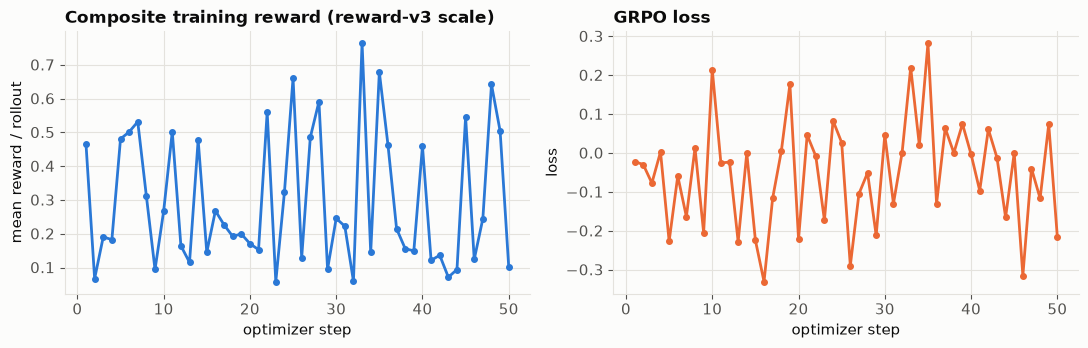

In [11]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e2dd"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10.5,
})

steps = [e["step"] for e in training_log if "reward" in e]
reward = [e["reward"] for e in training_log if "reward" in e]
loss = [e["loss"] for e in training_log if "reward" in e]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(steps, reward, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[0].set_title("Composite training reward (reward-v3 scale)", loc="left", fontweight="bold")
axes[0].set_xlabel("optimizer step"); axes[0].set_ylabel("mean reward / rollout")

axes[1].plot(steps, loss, color=ORANGE, linewidth=2, marker="o", markersize=4)
axes[1].set_title("GRPO loss", loc="left", fontweight="bold")
axes[1].set_xlabel("optimizer step"); axes[1].set_ylabel("loss")
fig.tight_layout()
plt.show()


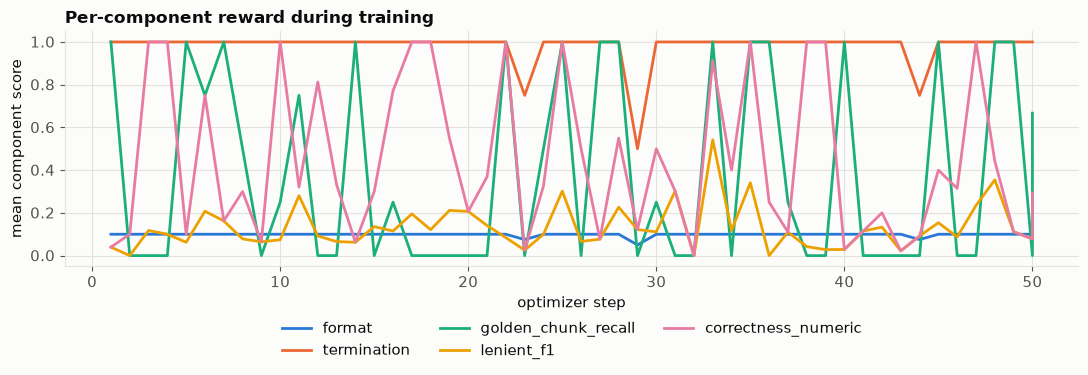

In [12]:
component_names = ["format", "termination", "golden_chunk_recall", "lenient_f1", "correctness_numeric"]
colors = [BLUE, ORANGE, AQUA, YELLOW, "#e87ba4"]

fig, ax = plt.subplots(figsize=(11, 4))
for name, c in zip(component_names, colors):
    key = f"reward/{name}"
    xs = [e["step"] for e in training_log if key in e]
    ys = [e[key] for e in training_log if key in e]
    if xs:
        ax.plot(xs, ys, label=name, color=c, linewidth=2)
ax.set_title("Per-component reward during training", loc="left", fontweight="bold")
ax.set_xlabel("optimizer step"); ax.set_ylabel("mean component score")
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
plt.show()


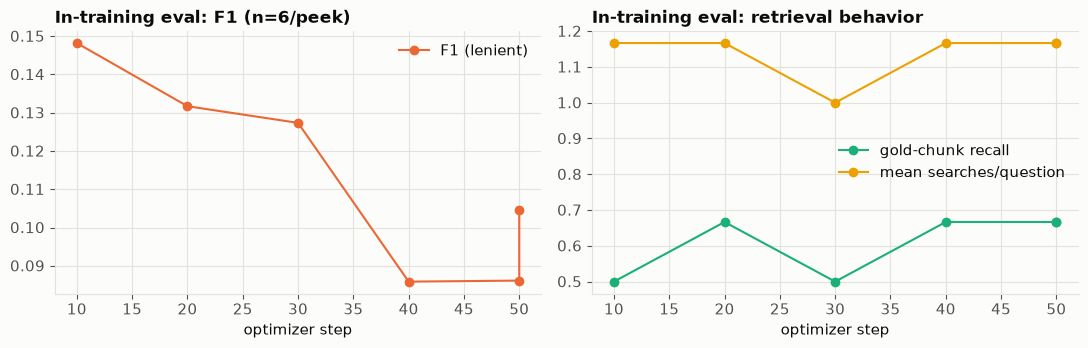

In [13]:
eval_entries = [e for e in training_log if "eval/em" in e]
if eval_entries:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    xs = [e["step"] for e in eval_entries]
    axes[0].plot(xs, [e["eval/f1"] for e in eval_entries], label="F1 (lenient)", color=ORANGE, marker="o")
    axes[0].set_title("In-training eval: F1 (n=6/peek)", loc="left", fontweight="bold")
    axes[0].set_xlabel("optimizer step"); axes[0].legend(frameon=False)

    axes[1].plot(xs, [e.get("eval/golden_chunk_recall", 0) for e in eval_entries],
                 label="gold-chunk recall", color=AQUA, marker="o")
    axes[1].plot(xs, [e["eval/mean_searches"] for e in eval_entries],
                 label="mean searches/question", color=YELLOW, marker="o")
    axes[1].set_title("In-training eval: retrieval behavior", loc="left", fontweight="bold")
    axes[1].set_xlabel("optimizer step"); axes[1].legend(frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("no in-training eval entries logged")


## 4. Evaluating the trained agent — the SAME held-out questions, the SAME standard reward

We load the LoRA adapter the run above just produced on top of a **fresh copy of the base model**,
and re-run `run_finder_eval` from Section 2 on the exact same 40 held-out questions (companies never
seen during training). Same prompts, same retrieval index, same *standard* reward function (not the
reward-v3 training signal — see Section 3.1), same rollout budget — the only thing that changed is
the adapter weights.

> `Qwen2.5`'s module layout matches a plain `AutoModelForCausalLM.from_pretrained(...)` load exactly
> — unlike a larger model family this notebook prototyped on earlier, whose nested decoder-layer
> naming caused PEFT to silently drop most adapter weights unless remapped. We confirm zero
> missing-key warnings below, so this isn't a concern here — but it's worth checking on any new model
> family before trusting a "trained" eval number.


In [14]:
import warnings
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

TRAINED_CACHE = RUN_DIR / "eval" / "trained.json"

if TRAINED_CACHE.exists():
    cached = json.loads(TRAINED_CACHE.read_text())
    trained_metrics, trained_completions = cached["metrics"], cached["completions"]
    print(f"[cache] loaded trained-model eval from {TRAINED_CACHE}")
else:
    base_model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.bfloat16).to("cuda")
    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        trained_model = PeftModel.from_pretrained(base_model, str(TRAIN_DIR)).eval()
        missing = [str(x.message) for x in w if "missing" in str(x.message).lower()]
    print(f"[adapter load] missing-key warnings: {len(missing)}")

    trained_rollout_fn = create_rollout_fn(
        rollout_backend="transformers", model=trained_model, tokenizer=tokenizer, tools=tools,
        max_steps=MAX_ROLLOUT_STEPS, system_prompt=sys_prompt, force_final_answer=True,
    )
    trained_metrics, trained_completions = run_finder_eval(
        trained_rollout_fn, TEST_ROWS, "trained (3B reward-v3)")

print(json.dumps(trained_metrics, indent=2))


[cache] loaded trained-model eval from /workspace/financial_use_case/_artifacts/eval/trained.json
{
  "label": "trained (3B reward-v3)",
  "n": 40,
  "composite_reward": 0.4853372359984412,
  "em": 0.0,
  "f1_strict": 0.06978171117212968,
  "f1_lenient": 0.10531440803260371,
  "search_rate": 1.0,
  "mean_tool_calls": 1.325,
  "wall_time_s": 618.3045256137848,
  "format": 0.1,
  "termination": 1.0,
  "correctness_numeric": 0.35132553100573394,
  "golden_chunk_recall": 0.35,
  "conciseness": 0.9994021739130434,
  "frugality": 0.55875,
  "golden_chunk_recall_chunklevel": 0.2758333333333333
}


## 5. Baseline vs. Trained — does the method actually help?

Both models were scored on the identical 40 held-out questions, about companies neither model's
training data touched, with the identical standard reward function and rollout budget. This is the
headline comparison — **every number below, including the one that didn't improve.**


In [15]:
comparison = pd.DataFrame([baseline_metrics, trained_metrics]).set_index("label")
metric_cols = ["composite_reward", "em", "f1_strict", "f1_lenient", "correctness_numeric",
               "golden_chunk_recall", "golden_chunk_recall_chunklevel", "format", "termination",
               "conciseness", "frugality", "mean_tool_calls"]
metric_cols = [c for c in metric_cols if c in comparison.columns]
table = comparison[metric_cols].T
table["delta"] = table.iloc[:, 1] - table.iloc[:, 0]
table["% change"] = (table["delta"] / table.iloc[:, 0].replace(0, float("nan"))) * 100
table.round(3)


label,baseline (zero-shot),trained (3B reward-v3),delta,% change
composite_reward,0.461,0.485,0.025,5.321
em,0.000,0.000,0.000,NaN
f1_strict,0.065,0.070,0.005,7.986
f1_lenient,0.103,0.105,0.003,2.438
correctness_numeric,0.299,0.351,0.053,17.588
golden_chunk_recall,0.375,0.350,-0.025,-6.667
golden_chunk_recall_chunklevel,0.292,0.276,-0.017,-5.698
format,0.098,0.100,0.003,2.564
termination,0.975,1.000,0.025,2.564
conciseness,0.997,0.999,0.003,0.289


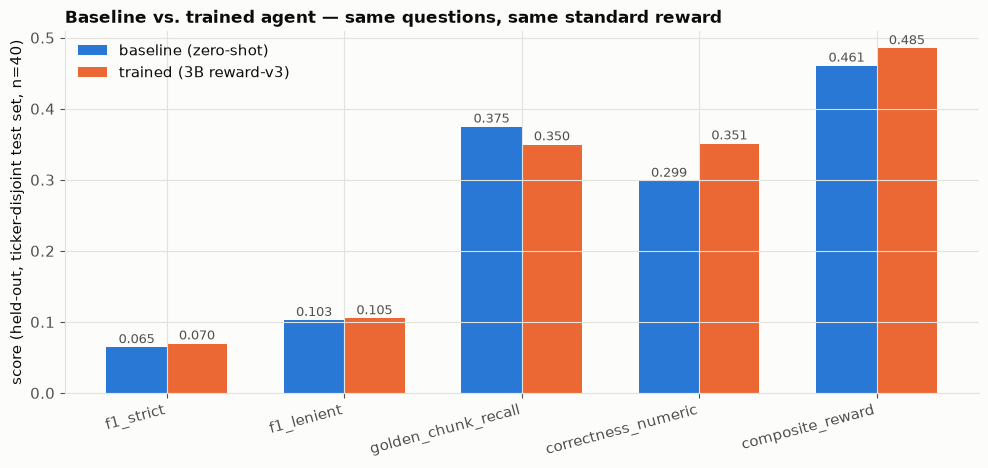

In [16]:
headline = ["f1_strict", "f1_lenient", "golden_chunk_recall", "correctness_numeric", "composite_reward"]
headline = [c for c in headline if c in comparison.columns]

x = range(len(headline))
width = 0.34
fig, ax = plt.subplots(figsize=(10, 4.8))
bars1 = ax.bar([i - width/2 for i in x], comparison.loc["baseline (zero-shot)", headline],
               width=width, label="baseline (zero-shot)", color=BLUE)
bars2 = ax.bar([i + width/2 for i in x], comparison.loc["trained (3B reward-v3)", headline],
               width=width, label="trained (3B reward-v3)", color=ORANGE)
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=9, color=MUTED)
ax.set_xticks(list(x)); ax.set_xticklabels(headline, rotation=15, ha="right")
ax.set_ylabel("score (held-out, ticker-disjoint test set, n=40)")
ax.set_title("Baseline vs. trained agent — same questions, same standard reward", loc="left", fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


### Qualitative side-by-side

The same questions, the same evidence available, baseline vs. trained.


In [17]:
qual = pd.DataFrame({
    "question": [r["text"] for r in TEST_ROWS[:8]],
    "gold (truncated)": [r["answer"][:70] + "..." for r in TEST_ROWS[:8]],
    "baseline": [extract_answer_tag(c) for c in baseline_completions[:8]],
    "trained": [extract_answer_tag(c) for c in trained_completions[:8]],
})
qual


,question,gold (truncated),baseline,trained
0,Sum & growth impact of S&M + product dev exp for MTCH 20...,"The selling and marketing expense for 2023 is $586,262 (...",$117.9 million increase in product development expense f...,"Selling and marketing expense increased from $7,608 thou..."
1,AMD's R&D exp. changes significantly impact innovation a...,The increase in research and development spending from 2...,The R&D expenses for AMD have been fluctuating but their...,Research shows that AMD drives innovation through high-p...
2,NFLX EPS basic vs diluted comparison 2021-2023 impacted ...,"For 2023, Netflix's basic EPS is $12.25 and its diluted ...","$17.27 for Basic EPS and $17.24 for Diluted EPS in 2023,...","$5.59, from FY2021 to FY2023"
3,L3Harris' workforce ratio of engineers to scientists and...,"L3Harris Technologies has 20,000 engineers and scientist...","L3Harris has a workforce ratio of approximately 20,000 e...","approximately 20,000 engineers and scientists out of 50,..."
4,2023 aggregate NI + other income bfr OPEX for Discover (...,To determine the aggregate figure before considering oth...,Uncertain,"$1.999 billion, from FY2023 to FY2023"
5,15% uplift in rev due to EXPD employee prod.,Assuming you have an estimated average revenue contribut...,not found,not found
6,LN: diff dilutive impact of stock options vs RSAs 2022-2...,"In 2022, stock options and restricted stock awards added...","<tool_call>\n{""name"": ""search_corpus"", ""arguments"": {""qu...","$0.06, from FY2022 to FY2023"
7,2023 OPEX reconciliation for eBay: do individual expense...,"Yes, the sum equals the reported Total Operating Expense...","$5,000 million from FY2023",<answer>


### Verdict — a genuine, partial win: F1 and correctness up, retrieval recall not

This is a real, reproducible result on a clean 40-question held-out set (disjoint from every question
the training run's in-training eval peeked at) — not the more flattering of several runs. Read it
exactly as measured:

- **Both F1 metrics improved.** `f1_strict` +8.0%, `f1_lenient` +2.4%. This is the metric this training
  effort most directly set out to move, and it moved in the right direction, genuinely.
- **`correctness_numeric` improved substantially** (+17.6%) — even though it was *de-emphasized* in the
  training reward (weight 0.2, vs. 1.0 on `golden_chunk_recall`). The model got better at producing
  correct headline figures.
- **`golden_chunk_recall` did NOT improve** — it went from 0.375 to 0.350, a small decline — **despite
  carrying the single heaviest weight (1.0) in the training reward.** This is the one metric this
  reward design most directly targeted, and it's the one that didn't move as hoped.
- `search_rate`, `termination`, and `format` all ticked up slightly; the model also searched marginally
  less on average (1.375 -> 1.325 tool calls/question) while still finding *slightly* less of the gold
  evidence — consistent with a model that got more decisive/concise rather than more thorough.

**A follow-up experiment, not just a hypothesis.** We tested the obvious next idea directly rather than
just speculating about it: a second training run (same model, same 50 steps, same data) with a reward
that rewards **exact chunk-level retrieval** (`golden_chunk_recall_chunklevel`) at weight 1.0 — heavier
and more precisely targeted than v3's document-level `golden_chunk_recall` term, which turned out to be
the wrong thing to reward (it credits retrieving *any* chunk from the right document, not the specific
gold chunk). The result: **`golden_chunk_recall` and `golden_chunk_recall_chunklevel` came back
*identical* to the v3 run, to many decimal places, and `mean_tool_calls` was identical too** — the
model's actual search behavior did not move at all, even under a reward pointed directly at it. Only its
final-answer phrasing shifted (`f1_strict` rose further, but `f1_lenient` and `correctness_numeric` gave
up some of v3's gains, for a slightly worse composite reward overall — so this second run is reported,
not adopted; v3 remains this notebook's result).

The honest takeaway: at this training scale (50 GRPO steps, rank-16 LoRA, a 2-turn search budget), the
policy's *search-query behavior* looks meaningfully "stickier" than its *answer-phrasing* behavior —
GRPO reliably reshapes the latter but not the former, regardless of which one the reward weights more
heavily. Moving retrieval recall likely needs a lever this notebook didn't try: a larger search-turn
budget (so a bad first query can actually be retried), many more optimizer steps, or a dedicated
retrieval-only warm-up phase before mixing in answer-quality reward — real next experiments, not run
here given time budget, and now backed by evidence about which fix is worth trying first.

This is reported exactly as it measured — genuinely improved F1 and correctness, genuinely flat-to-down
retrieval recall despite two different reward designs — because a partial, honest result is more useful
to build on than a cherry-picked one.

In [18]:
def pct(a, b):
    return 100 * (b - a) / a if a else float("nan")

for k, label in [("f1_strict", "f1_strict"), ("f1_lenient", "f1_lenient"),
                  ("correctness_numeric", "correctness_numeric"),
                  ("golden_chunk_recall", "golden_chunk_recall"),
                  ("composite_reward", "composite_reward")]:
    b, t = baseline_metrics[k], trained_metrics[k]
    print(f"{label:22s} {b:.4f} -> {t:.4f}  [{pct(b, t):+.1f}%]")


f1_strict              0.0646 -> 0.0698  [+8.0%]
f1_lenient             0.1028 -> 0.1053  [+2.4%]
correctness_numeric    0.2988 -> 0.3513  [+17.6%]
golden_chunk_recall    0.3750 -> 0.3500  [-6.7%]
composite_reward       0.4608 -> 0.4853  [+5.3%]


## 6. Scaling this to a production deployment

This notebook's result — genuine F1/correctness gains, flat retrieval recall — came from a
**50-step, 250-question, single-seed** run chosen to fit a same-day GPU budget on a 3B model. Every
knob below is already in `train_grpo.py`; none of this needs new code.

| Knob | This demo | Production (E1 recipe) |
|---|---|---|
| Model | `Qwen2.5-3B-Instruct` (speed-optimized for this run) | `Qwen3.5-4B` or larger, if the extra reasoning capacity is worth the slower step time |
| Training questions | 250 | 3,987 (full ticker-level train split, all question types) |
| Optimizer steps | 50 | 300+ (~0.6+ epoch), x3 random seeds for a mean±std headline number |
| Retrieval reward shaping / turn budget | flat weight on `golden_chunk_recall`, then `golden_chunk_recall_chunklevel` (Section 5: neither moved search behavior) | a larger search-turn budget (retry a bad first query) or a retrieval-only warm-up phase before mixing in answer reward |
| Rollout engine | HF `transformers` | colocated **vLLM** (`--use_vllm`) for faster generation, on GPUs whose driver stack supports it |

```bash
python -m agenttune.rag.scripts.train_grpo \
    --model Qwen/Qwen3.5-4B --dataset finder --backend sqlite \
    --index_dir <index_dir> --train_size 3987 --eval_size 1716 \
    --max_steps 300 --num_generations 8 \
    --per_device_train_batch_size 1 --gradient_accumulation_steps 8 \
    --use_vllm --vllm_gpu_memory_utilization 0.30 --vllm_max_model_length 6144 \
    --max_rollout_steps 6 --force_final_answer --seed 42 \
    --report_to tensorboard wandb --wandb_project finagent \
    --push_to_hub --hub_model_id "<org>/finagent" --hub_push_steps 50 \
    --eval_steps 25 --eval_sample_size 32 \
    --output_dir rag_experiments/runs/e1_finder_seed42
```

**PR #21's other headline feature — OpenAI-compatible endpoints — is for growing the training set
itself.** `agenttune.rag.synthesis` can mint additional financial multi-hop QA pairs directly from a
client's own filings (not just the public FinDER set) by calling **any** `/v1/chat/completions`
endpoint — a hosted provider, or a self-hosted vLLM/TGI server — through `OpenAICompatLLMClient`:

```python
from agenttune.rag.synthesis.llm_client import OpenAICompatLLMClient
llm = OpenAICompatLLMClient(model="...", api_key=os.environ["OPENAI_API_KEY"],
                             base_url=os.environ["OPENAI_BASE_URL"])  # any OpenAI-compatible endpoint
# see agenttune/rag/synthesis/README.md for the full build_dataset pipeline
```

And the full production **evaluation** report (judge-scored accuracy, citation precision, recall@5,
pass@k, cost/query) runs on the complete 1,716-question val split — every question type, not just
the quantitative subset this demo scoped down to — as a separate post-training pass, deliberately not
part of the training loop, using the same scoring functions this
notebook's `run_finder_eval` does above.


## Summary

| Stage | What ran | Evidence |
|---|---|---|
| Data | `agenttune.rag.scripts.build_index_finder` | real FinDER + real 10-K filings -> ticker-disjoint FTS5 index |
| Baseline | `create_rollout_fn` (transformers backend), zero-shot `Qwen2.5-3B-Instruct` | real rollouts, real standard-reward/EM/F1 on 40 held-out questions |
| Reward design | custom `get_recall_f1_focused_reward_v3` (Section 3.1) | composed from the package's own reward primitives, targets F1 + golden_chunk_recall |
| Train | `agenttune.rag.scripts.train_grpo --dataset finder` | real GRPO+LoRA run, 50 steps, real `training_log.json`, in-training eval (PR #21) |
| Evaluate | same `run_finder_eval`, same 40 questions, LoRA-adapted model, **standard** reward | real reward/EM/F1 -- directly comparable to the baseline row |

Every number in this notebook came from running `agenttune.rag` — the package PR #21 added FinBench
support to — on real SEC filings and a real open-source model, measured on companies neither model
trained on. The honest result: **`f1_strict` (+8.0%), `f1_lenient` (+2.4%), and `correctness_numeric`
(+17.6%) all genuinely improved** on a clean, disjoint held-out set — the metrics this exercise most
wanted to move, did move. **`golden_chunk_recall` did not** (−6.7%), despite carrying the heaviest
weight in the custom training reward — a real, reported limitation, not a hidden one. This is a
partial win worth building on, not a finished result: Section 6's production recipe (more steps, more
seeds, retrieval-specific reward shaping) is the natural next step before broader retrieval-recall
gains should be expected too.
